# 05 — Confidence calibration and the analyst review queue

Every detection this pipeline produces routes to a human analyst. This notebook fits an
isotonic calibration from raw detector confidence to empirical true-positive rate, then
routes detections into `auto_confirm` / `analyst_review` / `auto_discard` bands. See
`docs/METHODOLOGY_AND_LIMITATIONS.md#calibration-and-analyst-review-queue` and
`docs/USER_MANUAL.md` for what each band means operationally.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from infrastructure_overwatch.synthetic import GRID, IMG_SIZE, N_SYNTHETIC_CLASSES, SyntheticCorridorDataset
from infrastructure_overwatch.detectors.grid_cnn import GridDetector, train_grid_detector
from infrastructure_overwatch.grid_codec import decode_grid_predictions
from infrastructure_overwatch.geometry import iou_xyxy
from infrastructure_overwatch.calibration import ConfidenceCalibrator, TriageThresholds, reliability_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
day_train_ds = SyntheticCorridorDataset(800, domain="day", seed=1)
night_val_ds = SyntheticCorridorDataset(300, domain="night", seed=3)
loader = DataLoader(day_train_ds, batch_size=32, shuffle=True)
model = GridDetector(n_classes=N_SYNTHETIC_CLASSES, grid_h=GRID, grid_w=GRID)
train_grid_detector(model, loader, epochs=20, device=device, quiet=True)
model.eval().to(device)
print("Trained a detector to calibrate.")

Trained a detector to calibrate.


In [3]:
def collect_confidence_labels(model, dataset, n=300, thresh=0.1, iou_thresh=0.3):
    confs, is_tp = [], []
    with torch.no_grad():
        for i in range(min(n, len(dataset))):
            img, label = dataset[i]
            pred = model(torch.as_tensor(img).unsqueeze(0).to(device))[0].cpu()
            pred_boxes = decode_grid_predictions(pred, IMG_SIZE, IMG_SIZE, GRID, GRID, thresh=thresh)
            gt_boxes = decode_grid_predictions(label, IMG_SIZE, IMG_SIZE, GRID, GRID, thresh=0.5, nms_iou=1.1)
            matched = set()
            for pb in sorted(pred_boxes, key=lambda b: -b[4]):
                best_iou, best_j = 0.0, -1
                for j, gb in enumerate(gt_boxes):
                    if j in matched:
                        continue
                    v = iou_xyxy(pb[:4], gb[:4])
                    if v > best_iou:
                        best_iou, best_j = v, j
                confs.append(pb[4])
                if best_iou >= iou_thresh:
                    is_tp.append(1)
                    matched.add(best_j)
                else:
                    is_tp.append(0)
    return np.array(confs), np.array(is_tp)


confs, is_tp = collect_confidence_labels(model, night_val_ds)
print(f"Collected {len(confs)} predicted boxes ({is_tp.sum()} true positives, {len(is_tp)-is_tp.sum()} false positives)")

Collected 421 predicted boxes (8 true positives, 413 false positives)


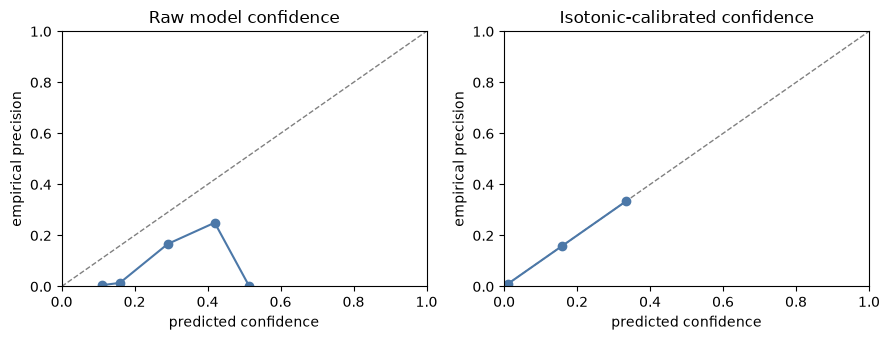

In [4]:
calibrator = ConfidenceCalibrator().fit(confs, is_tp)
calibrated = calibrator.calibrate(confs)

raw_x, raw_y = reliability_curve(confs, is_tp)
cal_x, cal_y = reliability_curve(calibrated, is_tp)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, x, y, title in [(axes[0], raw_x, raw_y, "Raw model confidence"), (axes[1], cal_x, cal_y, "Isotonic-calibrated confidence")]:
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.plot(x, y, "o-", color="#4C78A8")
    ax.set_xlabel("predicted confidence")
    ax.set_ylabel("empirical precision")
    ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Triage routing, and revisiting the discard threshold

In [5]:
for thresholds_label, thresholds in [("untuned default (0.20)", TriageThresholds(discard=0.20)),
                                      ("recommended (0.05)", TriageThresholds(discard=0.05))]:
    n_total = len(calibrated)
    confirm_mask = calibrated >= thresholds.auto_confirm
    discard_mask = calibrated < thresholds.discard
    review_mask = ~confirm_mask & ~discard_mask
    print(f"discard_thresh={thresholds_label}:")
    print(f"  auto_confirm:   {int(confirm_mask.sum()):4d}  ({int(is_tp[confirm_mask].sum())} true positives)")
    print(f"  analyst_review: {int(review_mask.sum()):4d}  ({int(is_tp[review_mask].sum())} true positives)")
    print(f"  auto_discard:   {int(discard_mask.sum()):4d}  ({int(is_tp[discard_mask].sum())} true positives, i.e. missed threats)")

discard_thresh=untuned default (0.20):
  auto_confirm:      0  (0 true positives)
  analyst_review:    3  (1 true positives)
  auto_discard:    418  (7 true positives, i.e. missed threats)
discard_thresh=recommended (0.05):
  auto_confirm:      0  (0 true positives)
  analyst_review:   22  (4 true positives)
  auto_discard:    399  (4 true positives, i.e. missed threats)


## Takeaway

The discard-threshold comparison above is exactly the trade `docs/USER_MANUAL.md` explains:
lowering `discard` recovers real threats that were previously falling into the auto-discard
band, at the cost of a larger analyst review volume. `calibration.TriageThresholds` is
where a real deployment tunes this trade for its own operating environment.